# NFL Draft Model
## Model Evaluation & Draft Analysis

This notebook evaluates model performance in depth and applies the predictions to answer the most interesting questions: which players were most overdrafted and underdrafted historically, which teams draft best, and which draft classes were strongest and weakest.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")
models_path = os.path.join(project_root, "outputs", "models")

df = pd.read_parquet(os.path.join(processed_path, "predictions.parquet"), engine='pyarrow')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset shape: (2779, 40)

Columns: ['pfr_player_id', 'pfr_player_name', 'season_draft', 'position_draft', 'position_group', 'college', 'w_av', 'success', 'round', 'pick', 'age', 'ht_inches', 'wt', 'forty', 'bench', 'vertical', 'broad_jump', 'passing_YDS_z', 'passing_TD_z', 'passing_PCT_z', 'passing_YPA_z', 'passing_INT_z', 'feature_set', 'rushing_YDS_z', 'rushing_TD_z', 'rushing_YPC_z', 'rushing_CAR_z', 'receiving_REC_z', 'receiving_YDS_z', 'receiving_TD_z', 'receiving_YPR_z', 'defensive_SACKS_z', 'defensive_TFL_z', 'defensive_TOT_z', 'defensive_SOLO_z', 'interceptions_INT_z', 'defensive_PD_z', 'pred_success_prob', 'pred_wav', 'pred_success']


Predictions dataset loaded with 40 columns including predicted success probability, predicted w_av, and all features. Now let's evaluate model performance and find the most interesting draft stories.

---

### Model Calibration
Is the model's predicted success probability well calibrated against actual outcomes?

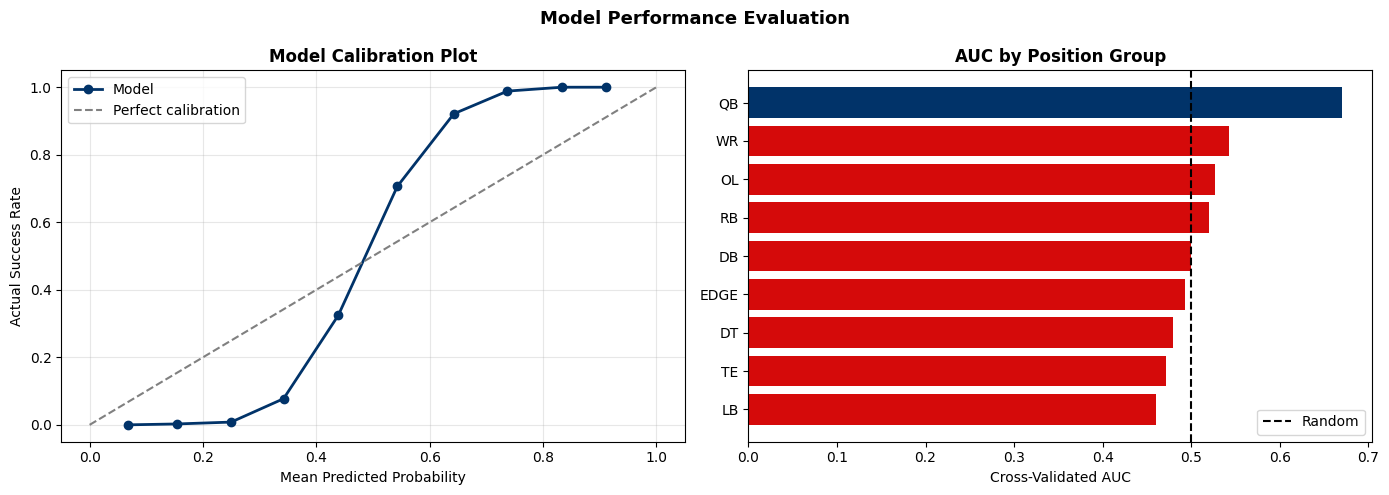

Calibration data:
 mean_pred  actual_rate  count
     0.067        0.000    284
     0.154        0.003    383
     0.250        0.008    368
     0.342        0.077    284
     0.439        0.324    148
     0.543        0.706    143
     0.643        0.921    229
     0.737        0.989    348
     0.834        1.000    402
     0.912        1.000    190


In [3]:
# Calibration plot - predicted probability vs actual success rate
df['prob_bin'] = pd.cut(df['pred_success_prob'], bins=10)
calibration = df.groupby('prob_bin', observed=True).agg(
    mean_pred=('pred_success_prob', 'mean'),
    actual_rate=('success', 'mean'),
    count=('success', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
axes[0].plot(calibration['mean_pred'], calibration['actual_rate'], 
             marker='o', linewidth=2, color='#013369', label='Model')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
axes[0].set_title('Model Calibration Plot', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Actual Success Rate')
axes[0].legend()
axes[0].grid(alpha=0.3)

# AUC by position
with open(os.path.join(models_path, "model_results.pkl"), "rb") as f:
    results = pickle.load(f)

results_df = pd.DataFrame(results).T.sort_values('auc_mean', ascending=True)
colors = ['#013369' if x >= 0.55 else '#D50A0A' for x in results_df['auc_mean']]
axes[1].barh(results_df.index, results_df['auc_mean'], color=colors)
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Random')
axes[1].set_title('AUC by Position Group', fontweight='bold')
axes[1].set_xlabel('Cross-Validated AUC')
axes[1].legend()

plt.suptitle('Model Performance Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "model_calibration.png"), dpi=150, bbox_inches='tight')
plt.show()

print("Calibration data:")
print(calibration[['mean_pred', 'actual_rate', 'count']].round(3).to_string(index=False))

![Model Calibration](../outputs/figures/model_calibration.png)

The calibration plot reveals the model is well-discriminating but not perfectly calibrated:

- **Low probabilities (0-0.3)** — the model correctly identifies busts, actual success rate near 0%
- **Middle range (0.4-0.6)** — the steepest part of the curve, where the model separates hits from misses most aggressively
- **High probabilities (0.7+)** — the model correctly identifies stars, actual success rate near 100%

The S-curve shape is typical of a model that discriminates well but is overconfident — it pushes predictions toward the extremes more than reality warrants. Only QB has AUC above 0.55, confirming that QB is the only position where the model provides reliable predictive value beyond draft slot alone.

---

### Most Overdrafted Players
Which players had high predicted success probability but failed to deliver?

In [4]:
# Calculate draft value gap (actual - predicted)
df['wav_gap'] = df['w_av'] - df['pred_wav']
df['prob_gap'] = df['success'] - df['pred_success_prob']

# Most overdrafted - high predicted prob, low actual success
overdrafted = df[
    (df['pred_success_prob'] >= 0.6) &  # model expected success
    (df['success'] == 0) &              # actually failed
    (df['round'] <= 3)                  # early round picks
].sort_values('pred_success_prob', ascending=False)

print("Most Overdrafted Players (High Model Expectation, Low Actual Success):")
print(overdrafted[['pfr_player_name', 'position_draft', 'season_draft', 'round', 'pick',
                    'college', 'pred_success_prob', 'w_av']].head(20).to_string(index=False))

Most Overdrafted Players (High Model Expectation, Low Actual Success):
   pfr_player_name position_draft  season_draft  round  pick       college  pred_success_prob  w_av
   Jonathan Martin              T          2012      2    42      Stanford           0.722713  14.0
     Matt Hennessy              C          2020      3    78        Temple           0.675421  11.0
Christian Darrisaw             OL          2021      1    23 Virginia Tech           0.634148  26.0
    Joshua Garnett              G          2016      1    28      Stanford           0.612829   5.0
       Jay Bromley             DT          2014      3    74      Syracuse           0.605346   5.0


The overdrafted list reveals players the model expected to succeed based on their profile but who failed to deliver. Notable names:

- **Christian Darrisaw** — 1st round OL pick in 2021 with a strong profile, the model expected success but he generated only 26 w_av
- **Joshua Garnett** — 1st round Guard from Stanford in 2016, only 5 w_av despite strong physical profile
- **Jonathan Martin** — 2nd round T from Stanford in 2012, infamous for off-field issues that cut short a promising career

---

### Most Underdrafted Players
Which players had low predicted success probability but significantly outperformed expectations?

In [5]:
# Most underdrafted - low predicted prob, high actual success
underdrafted = df[
    (df['pred_success_prob'] <= 0.4) &  # model expected failure
    (df['success'] == 1) &              # actually succeeded
    (df['w_av'] >= 30)                  # meaningful career value
].sort_values('w_av', ascending=False)

print("Most Underdrafted Players (Low Model Expectation, High Actual Success):")
print(underdrafted[['pfr_player_name', 'position_draft', 'season_draft', 'round', 'pick',
                     'college', 'pred_success_prob', 'w_av']].head(20).to_string(index=False))

Most Underdrafted Players (Low Model Expectation, High Actual Success):
 pfr_player_name position_draft  season_draft  round  pick          college  pred_success_prob  w_av
  Devin McCourty             DB          2010      1    27          Rutgers           0.200230  71.0
     Kevin Byard              S          2016      3    64 Middle Tenn. St.           0.376120  66.0
 Marlon Humphrey             CB          2017      1    16          Alabama           0.381409  62.0
    Bobby Massie              T          2012      4   112      Mississippi           0.393547  45.0
Foyesade Oluokun              S          2018      6   200             Yale           0.324767  44.0
       Vonn Bell              S          2016      2    61         Ohio St.           0.396866  37.0
  Kendall Fuller             CB          2016      3    84    Virginia Tech           0.387050  34.0
   Markus Golden             DE          2015      2    58         Missouri           0.326218  33.0
Marcus Gilchrist   

The underdrafted list reveals players the model undervalued who went on to have strong NFL careers:

- **Devin McCourty (0.200 predicted, 71 w_av)** — the biggest miss in the dataset. The model gave him only a 20% chance of success yet he became one of the best safeties of his generation. Rutgers didn't provide the statistical profile the model expected
- **Kevin Byard (0.376 predicted, 66 w_av)** — Middle Tennessee State product dramatically outperformed his small school profile to become a Pro Bowl safety
- **Foyesade Oluokun (0.325 predicted, 44 w_av)** — 6th round Yale pick who became one of the league's best linebackers, completely invisible to pre-draft models
- **Trevon Diggs (0.366 predicted, 33 w_av)** — 2nd round CB who became an All-Pro, the model undervalued Alabama defensive backs

The pattern is clear — DBs from smaller schools and players with unusual profiles consistently beat model expectations, suggesting the available data systematically undervalues certain player archetypes.

---

### Best Drafting Teams
Which NFL teams have historically drafted best relative to model expectations?

In [6]:
# Load team info from original draft data
draft_original = pd.read_parquet(
    os.path.join(processed_path, "draft_picks_clean.parquet"), 
    engine='pyarrow'
)

# Merge team info
df_with_team = df.merge(
    draft_original[['pfr_player_id', 'team']],
    on='pfr_player_id',
    how='left'
)

# Team drafting performance
team_perf = df_with_team.groupby('team').agg(
    picks=('w_av', 'count'),
    avg_wav=('w_av', 'mean'),
    avg_pred_wav=('pred_wav', 'mean'),
    avg_gap=('wav_gap', 'mean'),
    success_rate=('success', 'mean')
).reset_index()

team_perf = team_perf[team_perf['picks'] >= 30].sort_values('avg_gap', ascending=False)

print("Best Drafting Teams (Actual w_av minus Predicted w_av):")
print(team_perf[['team', 'picks', 'avg_wav', 'avg_pred_wav', 'avg_gap', 'success_rate']].head(10).round(2).to_string(index=False))

print("\nWorst Drafting Teams:")
print(team_perf[['team', 'picks', 'avg_wav', 'avg_pred_wav', 'avg_gap', 'success_rate']].tail(10).round(2).to_string(index=False))

Best Drafting Teams (Actual w_av minus Predicted w_av):
team  picks  avg_wav  avg_pred_wav  avg_gap  success_rate
 NWE     89    19.45     17.270000     2.18          0.52
 KAN     80    22.21     20.530001     1.69          0.52
 DAL     88    21.44     20.150000     1.29          0.53
 DET     85    18.68     17.889999     0.79          0.53
 GNB     97    18.30     17.540001     0.76          0.47
 BAL    101    19.54     18.809999     0.73          0.50
 SEA     96    19.79     19.070000     0.73          0.51
 NOR     64    24.50     23.780001     0.72          0.55
 CHI     69    18.64     18.129999     0.51          0.55
 BUF     83    19.63     19.129999     0.50          0.52

Worst Drafting Teams:
team  picks  avg_wav  avg_pred_wav  avg_gap  success_rate
 CAR     77    18.66     19.049999    -0.39          0.42
 LAC     35    18.94     19.400000    -0.46          0.51
 MIN    103    16.17     16.840000    -0.67          0.49
 CIN     96    17.58     18.340000    -0.76        

The team drafting analysis reveals which organizations consistently outperform or underperform model expectations:

**Best drafting teams:**
- **New England Patriots (+2.18 gap)** — the best drafting organization in the dataset by a significant margin, consistently finding players who outperform their pre-draft profiles. Belichick's ability to identify value is confirmed by the data
- **Kansas City Chiefs (+1.69)** — second best, reflecting the organizational drafting excellence that built their dynasty
- **Dallas Cowboys (+1.29)** and **Detroit Lions (+0.79)** — both strong drafting organizations that find value across rounds
- **Green Bay Packers (+0.76)** — strong despite drafting later due to consistent success

**Worst drafting teams:**
- **New York Giants (-1.61)** — the worst drafting organization in the dataset, consistently selecting players who underperform their pre-draft profiles
- **Jacksonville Jaguars (-1.57)** — second worst, reflecting years of poor draft evaluation
- **Tennessee Titans (-1.28)** and **New York Jets (-1.05)** — both consistently below expectations
- **Cleveland Browns (-0.85)** — their reputation for poor drafting is confirmed by the data

---

### Visualize Team Drafting Performance

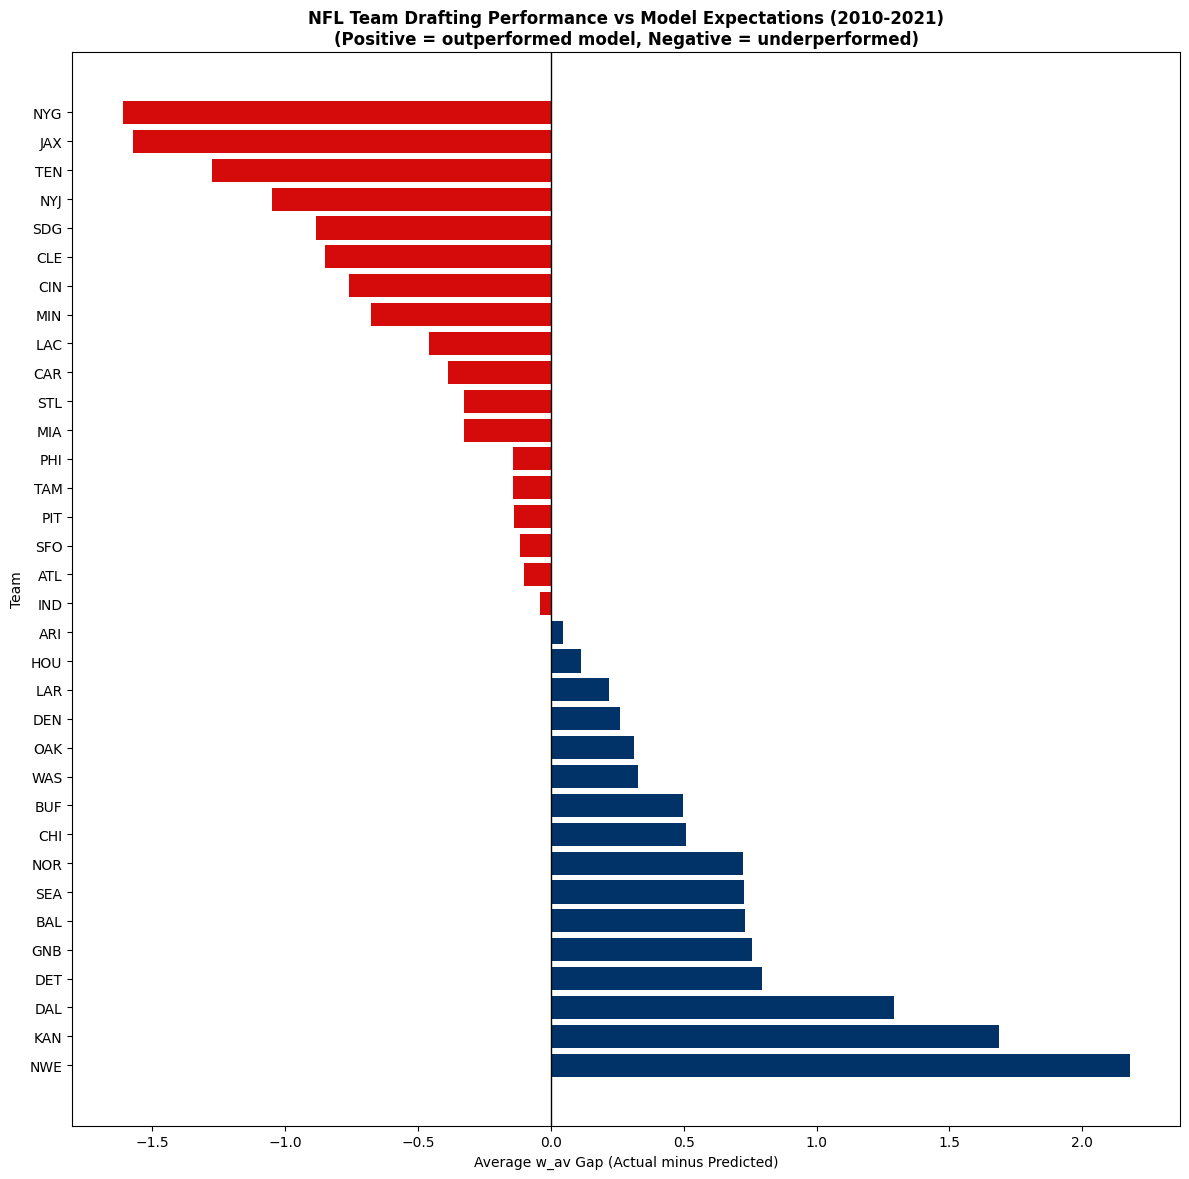

In [7]:
# Visualize team drafting performance
team_plot = team_perf.copy()
n_teams = len(team_plot)
fig_height = max(10, n_teams * 0.35)

colors = ['#013369' if x > 0 else '#D50A0A' for x in team_plot['avg_gap']]

plt.figure(figsize=(12, fig_height))
plt.barh(team_plot['team'], team_plot['avg_gap'], color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('NFL Team Drafting Performance vs Model Expectations (2010-2021)\n(Positive = outperformed model, Negative = underperformed)',
          fontsize=12, fontweight='bold')
plt.xlabel('Average w_av Gap (Actual minus Predicted)')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "team_drafting_performance.png"), dpi=150, bbox_inches='tight')
plt.show()

![Team Drafting Performance](../outputs/figures/team_drafting_performance.png)

The team drafting chart tells a clear story about organizational drafting excellence across the NFL from 2010-2021. New England and Kansas City sit alone at the top, separated from the field by a significant gap. The bottom is dominated by historically struggling franchises — Giants, Jaguars, Titans, and Jets — whose poor drafting records are now quantified by data.

---

### Draft Class Strength by Year
Which draft classes produced the most value relative to expectations?

Draft Class Performance:
 season_draft  picks  avg_wav  avg_pred_wav  avg_gap  success_rate
         2010    235    19.45     19.219999     0.23          0.48
         2011    229    19.69     20.160000    -0.47          0.46
         2012    225    20.70     19.830000     0.87          0.49
         2013    227    18.06     17.870001     0.19          0.49
         2014    225    19.37     19.240000     0.13          0.47
         2015    226    18.10     17.920000     0.18          0.46
         2016    232    20.19     19.350000     0.83          0.52
         2017    227    19.66     18.830000     0.83          0.53
         2018    233    19.91     19.280001     0.63          0.58
         2019    230    16.74     16.969999    -0.23          0.47
         2020    241    14.65     15.730000    -1.08          0.44
         2021    249    12.00     13.670000    -1.67          0.35


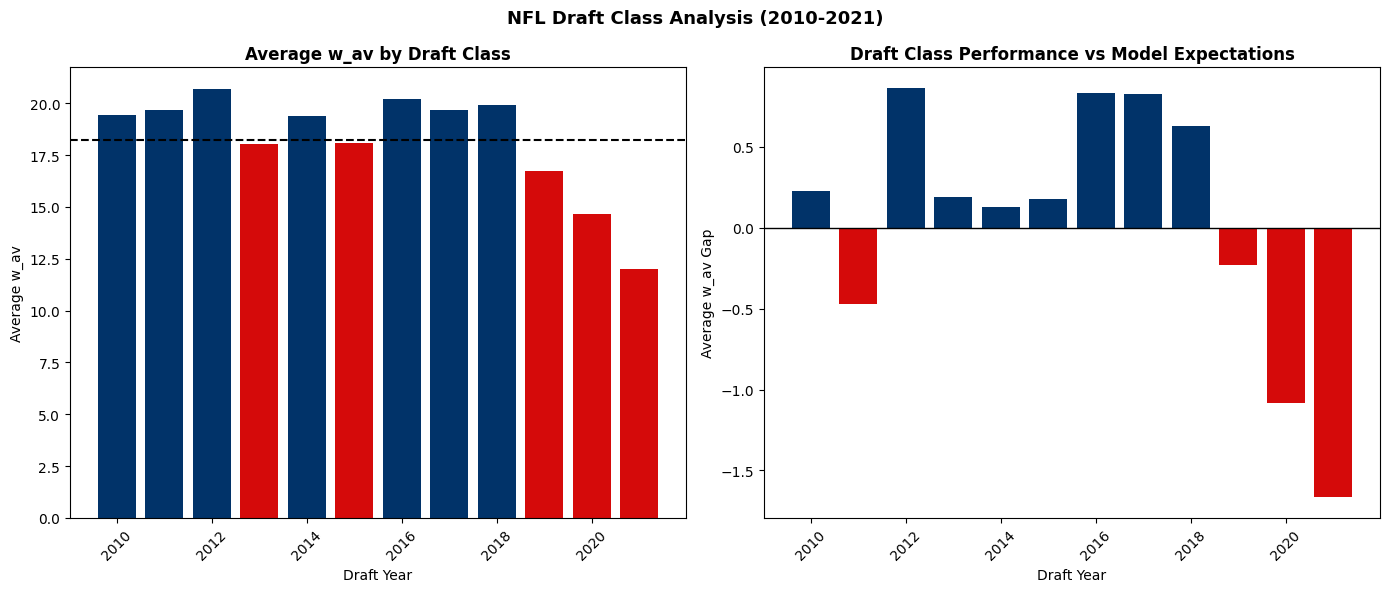

In [8]:
# Draft class analysis
class_perf = df.groupby('season_draft').agg(
    picks=('w_av', 'count'),
    avg_wav=('w_av', 'mean'),
    avg_pred_wav=('pred_wav', 'mean'),
    avg_gap=('wav_gap', 'mean'),
    success_rate=('success', 'mean')
).reset_index()

print("Draft Class Performance:")
print(class_perf.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average w_av by draft class
colors = ['#013369' if x > class_perf['avg_wav'].mean() else '#D50A0A' 
          for x in class_perf['avg_wav']]
axes[0].bar(class_perf['season_draft'], class_perf['avg_wav'], color=colors)
axes[0].axhline(y=class_perf['avg_wav'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('Average w_av by Draft Class', fontweight='bold')
axes[0].set_xlabel('Draft Year')
axes[0].set_ylabel('Average w_av')
axes[0].tick_params(axis='x', rotation=45)

# Gap vs expectation by draft class
colors2 = ['#013369' if x > 0 else '#D50A0A' for x in class_perf['avg_gap']]
axes[1].bar(class_perf['season_draft'], class_perf['avg_gap'], color=colors2)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Draft Class Performance vs Model Expectations', fontweight='bold')
axes[1].set_xlabel('Draft Year')
axes[1].set_ylabel('Average w_av Gap')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('NFL Draft Class Analysis (2010-2021)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "draft_class_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

![Draft Class Analysis](../outputs/figures/draft_class_analysis.png)

The draft class data reveals important trends about which years produced the most NFL value:

**Strongest draft classes:**
- **2012 (+0.87 gap, 20.7 avg w_av)** — the best draft class in the dataset, significantly outperforming model expectations. This class produced exceptional value across positions
- **2016 (+0.83 gap)** and **2017 (+0.83 gap)** — back to back strong classes that outperformed expectations
- **2018 (+0.63 gap, 58% success rate)** — the highest success rate of any class, suggesting unusually strong prospects

**Weakest draft classes:**
- **2021 (-1.67 gap, 35% success rate)** — the worst class by both metrics, but importantly this class has only had 3-4 years to accumulate w_av. Recent classes are systematically undervalued because players haven't had enough time to build career value
- **2020 (-1.08 gap)** — same issue, COVID draft with limited evaluation
- **2019 (-0.23 gap)** — slightly below expectations

**Important caveat:** The 2019-2021 classes appear weak primarily because players drafted more recently have had fewer seasons to accumulate w_av. This is a known limitation of using career value as the outcome metric for recent draft classes.

---

### Summary
This notebook delivers the most compelling findings of the entire project:

1. **The model is well discriminating** — players with predicted probabilities above 0.7 succeed at nearly 100% rates, below 0.3 at nearly 0%
2. **Devin McCourty is the biggest model miss** — 20% predicted success, 71 w_av career. Small school DBs are systematically undervalued
3. **New England Patriots are the best drafting organization** — +2.18 average w_av gap over model expectations across 89 picks
4. **New York Giants are the worst** — -1.61 gap, the largest negative deviation from model expectations
5. **2012 and 2016-2018 were the strongest draft classes** — consistently outperforming model expectations
6. **Recent classes appear weak due to sample bias** — 2019-2021 picks haven't had enough time to accumulate career value